## 1. Configuración Inicial y Carga de Datos

### Vamos a trabajar con el dataset de IBM HR Analytics, que contiene información de 1,470 empleados con 35 variables cada uno. El objetivo es entender qué factores llevan a un empleado a renunciar a su empleo. Empezamos con la configuración inicial

In [4]:
# En este paso importamos las librerías necesarias para el análisis de datos, la visualización y el preprocesamiento. 
# Luego, cargamos el dataset de empleados y realizamos una inspección inicial para entender su estructura y contenido.

import numpy as np # Para operaciones numéricas
import pandas as pd # Para manipulación de datos    
import matplotlib.pyplot as plt # Para visualización de datos
import seaborn as sns # Para visualización de datos con estilos
from scipy import stats # Para análisis estadístico
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder # Para preprocesamiento de datos
from sklearn.decomposition import PCA # Para reducción de dimensionalidad
import warnings # Para manejar advertencias y evitar que se muestren en la salida
warnings.filterwarnings('ignore') # Ignorar advertencias para una salida más limpia

# Configuramos el estilo de los gráficos y el tamaño de las figuras para una mejor visualización.
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted") # Establece el tema de Seaborn para gráficos con fondo blanco y paleta de colores suave
plt.rcParams['figure.figsize'] = (12, 6) # Establece el tamaño predeterminado de las figuras a 12 pulgadas de ancho y 6 pulgadas de alto
plt.rcParams['axes.titlesize'] = 16 # Establece el tamaño de los títulos de los ejes a 16 puntos

# Cargamos el  dataset
df = pd.read_csv('../Data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Inspeccionamos inicialmente el dataset para entender su estructura y contenido
print(f"Dimensiones del dataset: {df.shape}")
print(f"Filas: {df.shape[0]} empleados | Columnas: {df.shape[1]} variables")
print("\n--- Primeras filas del data set de empleados ---")
df.head() # Muestra las primeras filas del dataset para una vista previa de los datos

Dimensiones del dataset: (1470, 35)
Filas: 1470 empleados | Columnas: 35 variables

--- Primeras filas del data set de empleados ---


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [19]:
num_count = df.select_dtypes(include=[np.number]).shape[1]
cat_count = df.select_dtypes(include='object').shape[1]
print(f"Variables numéricas: {num_count} | Variables categóricas: {cat_count}")

Variables numéricas: 27 | Variables categóricas: 9


#### Con info() vemos los tipos de datos de cada columna. Teniendo en cuenta el número de variables categóricas y numéricas calculado anteriormente, se tiene claridad de qué tipo de tratamiento va a necesitar cada una más adelante.

In [14]:
# Revisión rápida de tipos de datos
print("Tipos de datos por columna:")
df.info()

Tipos de datos por columna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 

---
## Fase 2: Análisis Exploratorio de Datos (EDA)

Antes de profundizar en cada dimensión del análisis, se caracteriza la variable objetivo 
`Attrition`, cuya distribución determina el contexto de todo el EDA.

In [29]:
# Distribución de la variable objetivo
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

print("Distribución de Attrition:")
for label in attrition_counts.index:
    print(f"  {label}: {attrition_counts[label]} empleados ({attrition_pct[label]:.1f}%)")

Distribución de Attrition:
  No: 1233 empleados (83.9%)
  Yes: 237 empleados (16.1%)


El dataset presenta un desbalance notable: la clase minoritaria (`Attrition=Yes`) representa 
apenas el 16.1% de los registros, mientras que el 83.9% corresponde a empleados que 
permanecieron en la empresa. Este dato es fundamental para interpretar correctamente todos 
los análisis que siguen, ya que cualquier patrón o tasa de deserción debe evaluarse siempre 
en relación con ese 16.1% como línea base.

### 2.1 Valores faltantes

### Revisamos si hay datos ausentes. El resultado es cero nulos en todo el dataset, lo cual es bastante inusual y habla bien de la calidad de los datos. Aun así documentamos la estrategia que aplicaríamos si existieran: eliminación para menos del 5%, imputación con media o mediana para variables numéricas según su sesgo, y moda para categóricas

In [16]:
# Cuenta el número de valores nulos en cada columna del DataFrame
null_counts = df.isnull().sum() 
# Calcula el porcentaje de valores nulos en cada columna dividiendo el conteo de nulos por el número total de filas y multiplicando por 100
null_pct = (null_counts / len(df)) * 100 
# Combina el conteo de nulos y el porcentaje en un nuevo DataFrame llamado missing_df, con columnas 'Total_Nulos' y 'Porcentaje (%)'
missing_df = pd.concat([null_counts, null_pct], axis=1, keys=['Total_Nulos', 'Porcentaje (%)']) 

print("=" * 45)
print("   ANÁLISIS DE VALORES FALTANTES")
print("=" * 45)
cols_con_nulos = missing_df[missing_df['Total_Nulos'] > 0]

if cols_con_nulos.empty:
    print("✓ El dataset NO presenta valores nulos en ninguna columna.")
    print(f"  Total de celdas revisadas: {df.shape[0] * df.shape[1]:,}")
else:
    print(cols_con_nulos)

# Estrategia de tratamiento propuesta en caso de que existan valores faltantes en el dataset, dependiendo del porcentaje de nulos y su distribución.


   ANÁLISIS DE VALORES FALTANTES
✓ El dataset NO presenta valores nulos en ninguna columna.
  Total de celdas revisadas: 51,450


#### En caso de existir valores faltantes (aunque no se presenta en este dataset), la estrategia dependería del porcentaje:

  • < 5% y distribución aleatoria (MCAR) → Eliminación de filas afectadas.
    Ejemplo: 3 registros sin edad → se eliminan sin impacto estadístico.

  • 5–30% → Imputación:
      - Variables numéricas simétricas: imputar con la MEDIA.
      - Variables numéricas con sesgo:  imputar con la MEDIANA.
      - Variables categóricas:          imputar con la MODA.

  • > 30% → Evaluar si el patrón de ausencia es informativo. En ese caso,
    se crearía una columna binaria 'Es_Nulo_X' que capture ese patrón,
    y se aplicaría imputación para el valor original.


### 2.2 Detección de Valores Atípicos (Outliers)

Un **outlier** es un valor que se aleja mucho del resto. Pueden ser errores de medición o datos reales pero extremos (ej. un CEO con un salario 10 veces mayor al promedio).

**Métodos utilizados:**
- **Boxplot**: gráfico de caja. Los puntos fuera de los "bigotes" son potenciales outliers.
- **IQR (Rango Intercuartílico)**: matemáticamente define como outlier cualquier valor fuera de `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]`.
- **Z-score**: mide cuántas desviaciones estándar se aleja un punto de la media. Valores > 3 son outliers.

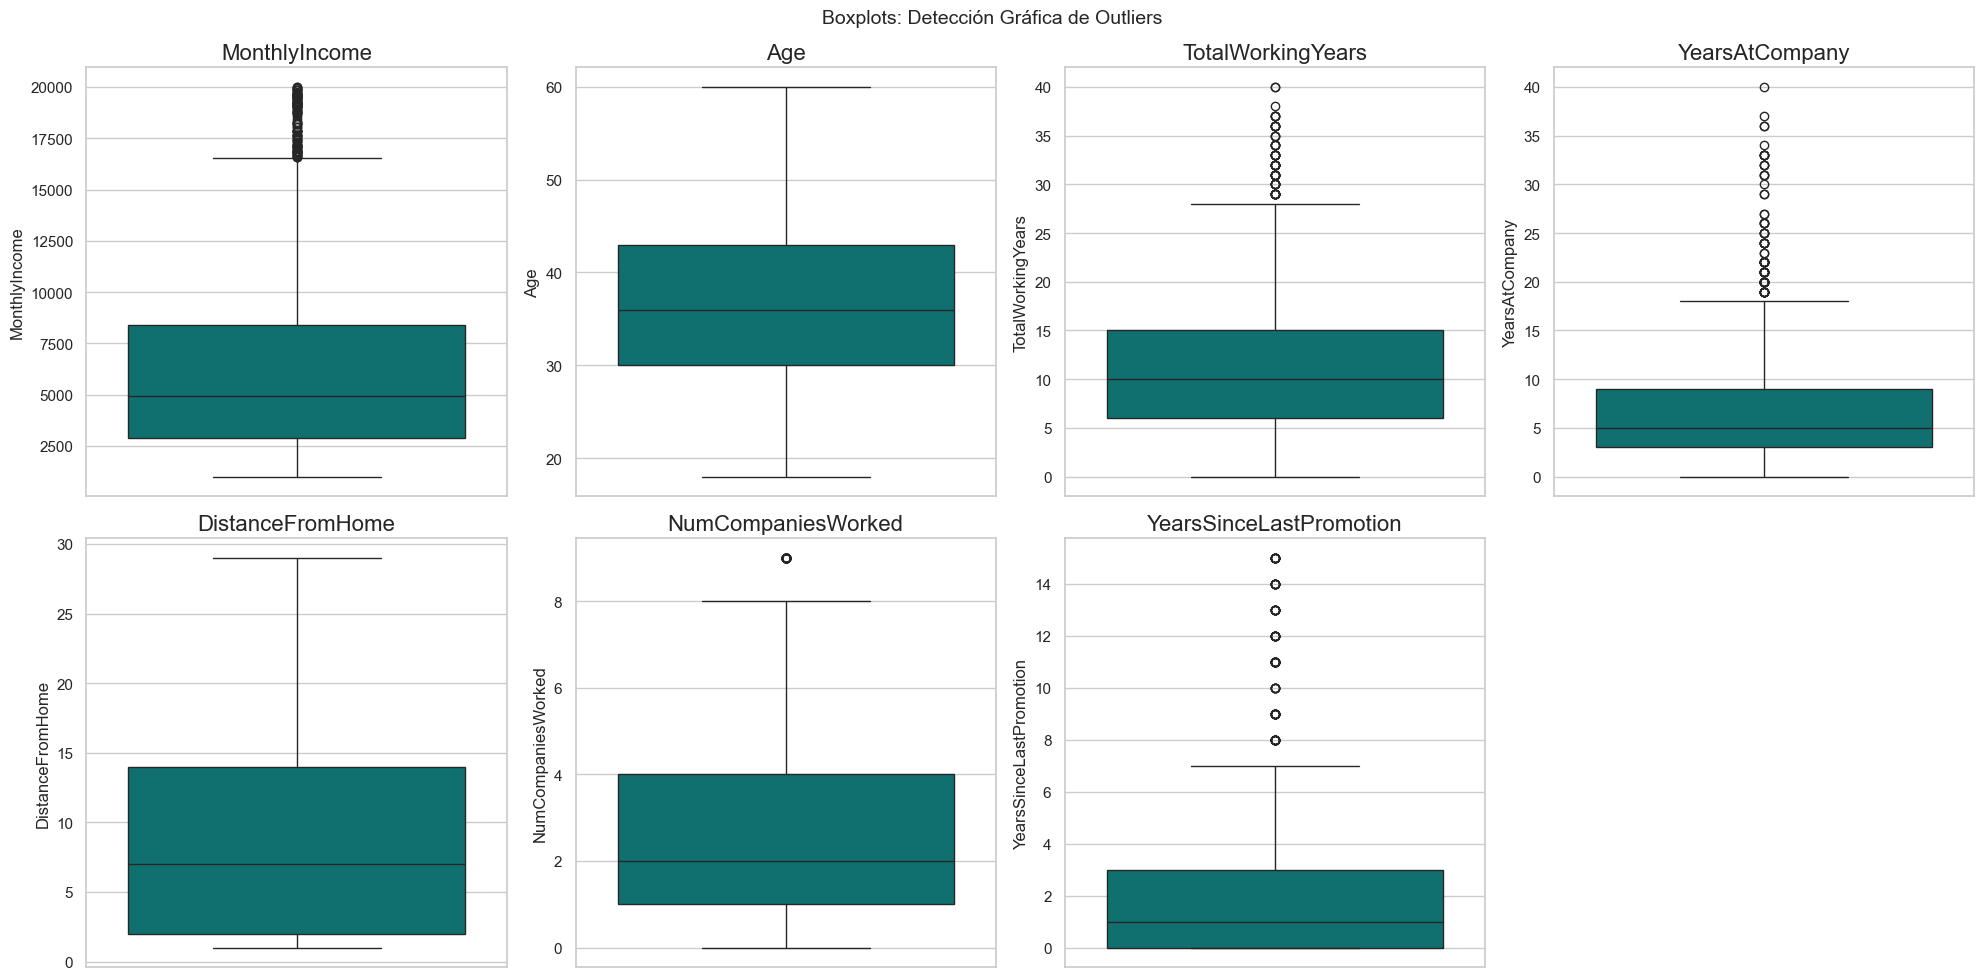

In [16]:
# Variables numéricas clave para análisis de outliers
# Estas variables se seleccionan por su relevancia en el contexto de recursos humanos y 
# su potencial para contener valores atípicos que podrían influir en el análisis de la rotación de empleados.
outlier_vars = ['MonthlyIncome', 'Age', 'TotalWorkingYears', 'YearsAtCompany',
                'DistanceFromHome', 'NumCompaniesWorked', 'YearsSinceLastPromotion']

# --- Boxplots ---
fig, axes = plt.subplots(2, 4, figsize=(20, 10)) # Crea una figura con una cuadrícula de 2 filas y 4 columnas para mostrar los boxplots de las variables seleccionadas
axes = axes.flatten() # Aplana la matriz de ejes para facilitar la iteración

for i, col in enumerate(outlier_vars): # Itera sobre las variables seleccionadas para crear un boxplot para cada una
    sns.boxplot(y=df[col], ax=axes[i], color='teal')
    axes[i].set_title(col)

axes[-1].set_visible(False)  # Ocultar el eje vacío
plt.suptitle('Boxplots: Detección Gráfica de Outliers', fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
# IQR: cálculo numérico de outliers
print("Detección de outliers por método IQR:")
print(f"{'Variable':<30} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Límite inf':>12} {'Límite sup':>12} {'N outliers':>12} {'%':>6}")
print("-" * 100)
for col in outlier_vars:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    n_out = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    pct = n_out / len(df) * 100
    print(f"{col:<30} {Q1:>8.2f} {Q3:>8.2f} {IQR:>8.2f} {lim_inf:>12.2f} {lim_sup:>12.2f} {n_out:>12} {pct:>5.1f}%")

Detección de outliers por método IQR:
Variable                             Q1       Q3      IQR   Límite inf   Límite sup   N outliers      %
----------------------------------------------------------------------------------------------------
MonthlyIncome                   2911.00  8379.00  5468.00     -5291.00     16581.00          114   7.8%
Age                               30.00    43.00    13.00        10.50        62.50            0   0.0%
TotalWorkingYears                  6.00    15.00     9.00        -7.50        28.50           63   4.3%
YearsAtCompany                     3.00     9.00     6.00        -6.00        18.00          104   7.1%
DistanceFromHome                   2.00    14.00    12.00       -16.00        32.00            0   0.0%
NumCompaniesWorked                 1.00     4.00     3.00        -3.50         8.50           52   3.5%
YearsSinceLastPromotion            0.00     3.00     3.00        -4.50         7.50          107   7.3%


In [17]:
# Cálculo de z-score
z_scores = pd.DataFrame()
for col in outlier_vars:
    z = np.abs(stats.zscore(df[col]))
    z_scores[col] = z

print("Cantidad de outliers por z-score (|z| > 3):")
for col in outlier_vars:
    n = (z_scores[col] > 3).sum()
    print(f"  {col}: {n} outliers ({n/len(df)*100:.1f}%)")

Cantidad de outliers por z-score (|z| > 3):
  MonthlyIncome: 0 outliers (0.0%)
  Age: 0 outliers (0.0%)
  TotalWorkingYears: 16 outliers (1.1%)
  YearsAtCompany: 25 outliers (1.7%)
  DistanceFromHome: 0 outliers (0.0%)
  NumCompaniesWorked: 0 outliers (0.0%)
  YearsSinceLastPromotion: 42 outliers (2.9%)


Análisis de los boxplots (outliers) para las variables numéricas clave:

- MonthlyIncome: hay 114 valores por encima del límite superior (16581), ~7.8% del dataset.
    Esto indica un grupo de empleados con ingresos muy altos respecto al resto.

- Age: no hay outliers según IQR (ningún valor fuera de [10.5, 62.5]), es un rango controlado.

- TotalWorkingYears: 63 outliers (>28.5 años), ~4.3%. Son trabajadores con trayectorias laborales muy largas.

- YearsAtCompany: 104 outliers (>18 años), ~7.1%. Empleados de larga permanencia en la compañía.

- DistanceFromHome: 0 outliers, la mayoría vive a distancias razonables (<=32 km).

- NumCompaniesWorked: 52 outliers (>8.5 empresas), ~3.5%. Se trata de empleados con historial laboral muy rotativo.

- YearsSinceLastPromotion: 107 outliers (>7.5 años), ~7.3%. Pueden indicar estancamiento en el desarrollo interno.

Conclusión:
1) Variables con mayor proporción de outliers: MonthlyIncome, YearsAtCompany, YearsSinceLastPromotion.
2) No se detectan outliers extremos en Age y DistanceFromHome.
3) La presencia de outliers en ingresos y años de servicio puede influir en el análisis de rotación.

**Decisión sobre tratamiento de outliers:**
Dado que este dataset proviene de un entorno corporativo real (IBM), los outliers identificados 
**no son errores de medición**, sino perfiles legítimos (ejecutivos con altos ingresos, empleados 
con larga trayectoria). Por tanto, se decide **conservarlos** en el análisis exploratorio. 
Sin embargo, en la Fase 3 de modelado se evaluará el uso de transformaciones robustas 
(como log o RobustScaler) para mitigar su influencia en algoritmos sensibles a la escala.

### 2.3 Análisis de Distribuciones

Se explora la forma de las variables numéricas más relevantes del dataset mediante histogramas 
combinados con curvas de densidad (KDE). Este análisis permite identificar el grado de asimetría 
de cada variable, detectar comportamientos no normales y determinar qué variables podrían 
requerir transformaciones en fases posteriores del análisis. Para cada gráfico se calcula 
automáticamente el coeficiente de sesgo (skew), donde valores cercanos a 0 indican simetría, 
valores positivos indican cola hacia la derecha y valores negativos cola hacia la izquierda.

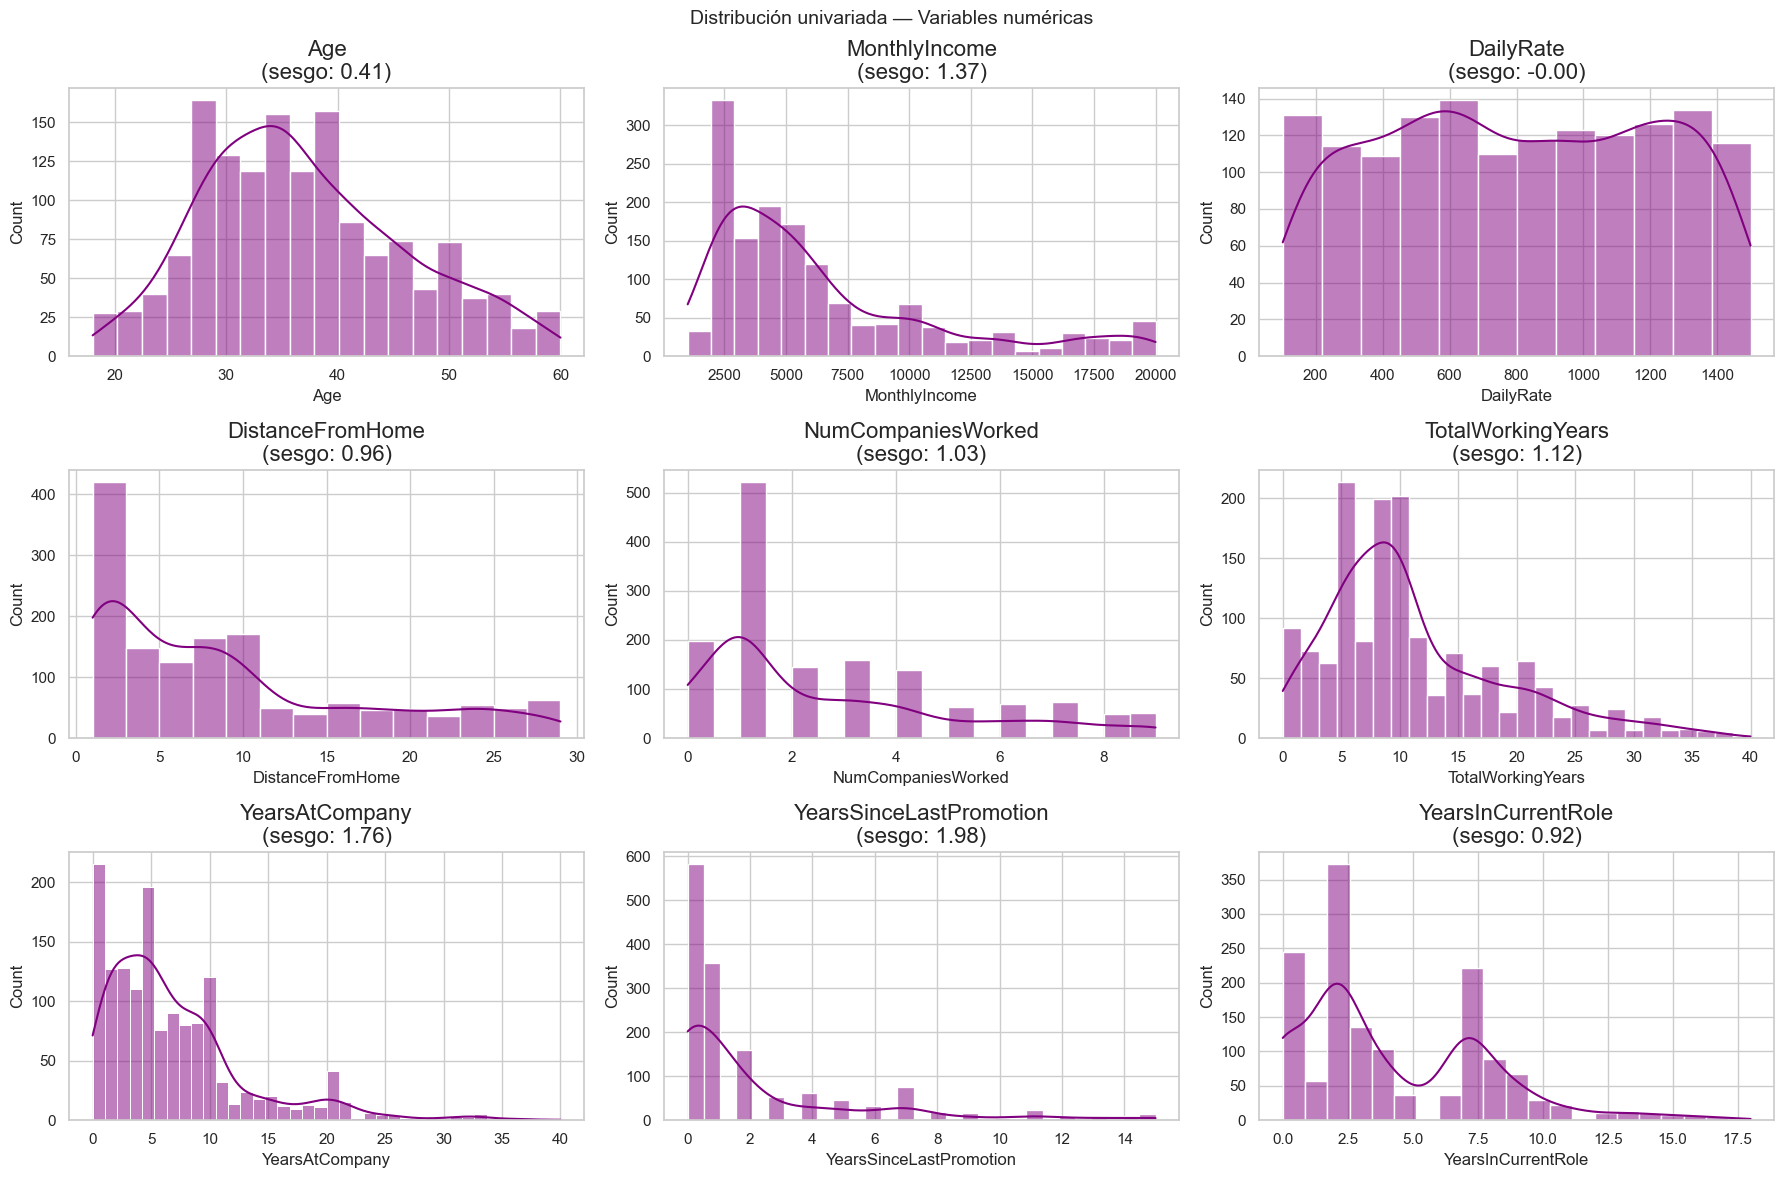

In [23]:
# Histogramas con KDE: todas las variables numéricas relevantes
num_vars = ['Age', 'MonthlyIncome', 'DailyRate', 'DistanceFromHome', 
            'NumCompaniesWorked', 'TotalWorkingYears', 'YearsAtCompany',
            'YearsSinceLastPromotion', 'YearsInCurrentRole']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_vars):
    sns.histplot(df[col], kde=True, ax=axes[i], color='purple')
    axes[i].set_title(f'{col}\n(sesgo: {df[col].skew():.2f})')

plt.suptitle('Distribución univariada — Variables numéricas', fontsize=14)
plt.tight_layout()
plt.show()

# Transformación sugerida:
# MonthlyIncome tiene un sesgo alto (1.37). Podría beneficiarse de una transformación logarítmica.

El análisis de distribuciones permite clasificar las variables en tres grupos:

**Variables con sesgo positivo alto (skew > 1.0) — candidatas a transformación logarítmica:**
- `MonthlyIncome`, `YearsAtCompany`, `YearsSinceLastPromotion` y `NumCompaniesWorked` presentan 
  colas largas hacia la derecha, lo que indica que la mayoría de los empleados se concentran 
  en valores bajos mientras una minoría ocupa valores extremos. Este comportamiento puede 
  perjudicar el rendimiento de modelos sensibles a la escala en la Fase 3.

**Variables con sesgo moderado (0.5 < skew ≤ 1.0):**
- `DistanceFromHome`, `TotalWorkingYears` y `YearsInCurrentRole` muestran cierta asimetría 
  positiva, pero menos pronunciada. Podrían beneficiarse de una estandarización en lugar de 
  transformación logarítmica.

**Variables aproximadamente normales (skew ≤ 0.5):**
- `Age` y `DailyRate` presentan distribuciones más simétricas y cercanas a la campana de Gauss, 
  por lo que no requieren transformaciones de forma para su uso en modelos estadísticos.

En general, la presencia de asimetría positiva en variables como el ingreso y la antigüedad es 
coherente con la realidad de cualquier organización: la mayoría de empleados tienen perfiles 
medios, mientras que los niveles más altos son minoritarios. Estas observaciones guiarán las 
decisiones de preprocesamiento en la siguiente fase.

### 2.4 Análisis Univariado

Se estudia cada variable de manera individual desde dos ángulos complementarios. Para las 
variables numéricas, se calculan estadísticos descriptivos clave (media, mediana, desviación 
estándar, mínimo, máximo, coeficiente de variación y sesgo), que permiten caracterizar la 
tendencia central, la dispersión y la asimetría de cada una sin depender de una visualización. 
Para las variables categóricas, se generan gráficos de barras con la frecuencia de cada 
categoría, lo que permite detectar desbalances en la composición de la muestra que podrían 
condicionar el análisis posterior.

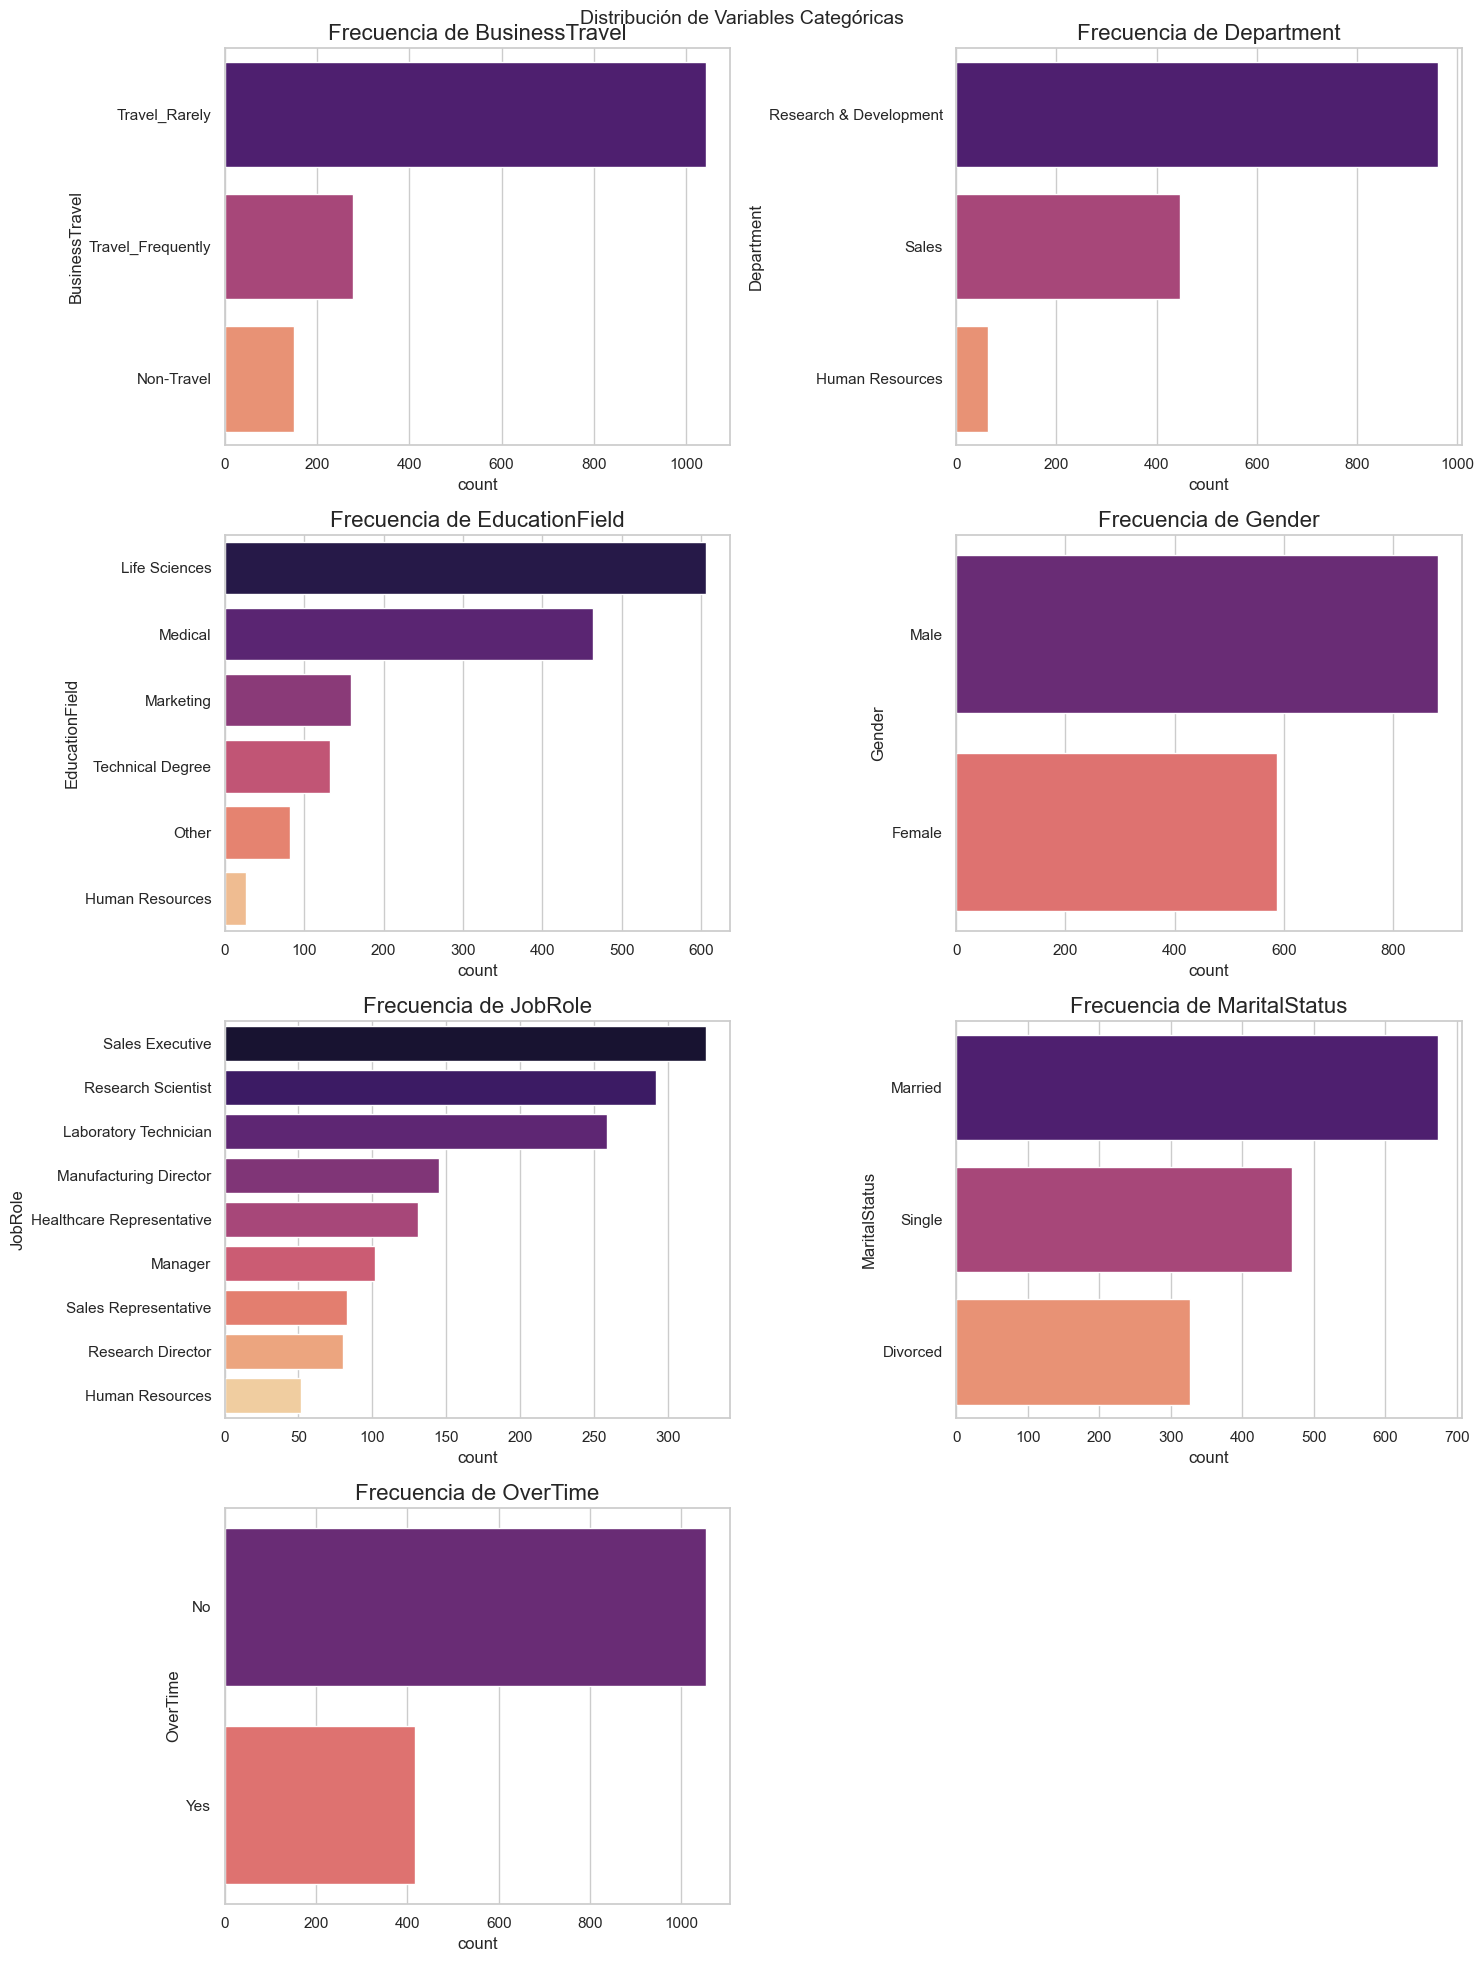

Estadísticos descriptivos — Variables numéricas:
                              mean      50%      std     min      max  CV (%)  skew
Age                          36.92     36.0     9.14    18.0     60.0    24.7  0.41
DailyRate                   802.49    802.0   403.51   102.0   1499.0    50.3 -0.00
DistanceFromHome              9.19      7.0     8.11     1.0     29.0    88.2  0.96
Education                     2.91      3.0     1.02     1.0      5.0    35.2 -0.29
EnvironmentSatisfaction       2.72      3.0     1.09     1.0      4.0    40.2 -0.32
HourlyRate                   65.89     66.0    20.33    30.0    100.0    30.9 -0.03
JobInvolvement                2.73      3.0     0.71     1.0      4.0    26.1 -0.50
JobLevel                      2.06      2.0     1.11     1.0      5.0    53.6  1.02
JobSatisfaction               2.73      3.0     1.10     1.0      4.0    40.4 -0.33
MonthlyIncome              6502.93   4919.0  4707.96  1009.0  19999.0    72.4  1.37
MonthlyRate               1

In [24]:
# --- Parte 1: Variables categóricas ---
cat_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

plt.figure(figsize=(15, 20))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(4, 2, i)
    sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='magma')
    plt.title(f'Frecuencia de {col}')

plt.suptitle('Distribución de Variables Categóricas', fontsize=14)
plt.tight_layout()
plt.show()  # ← FALTA ESTO en el código actual

# --- Parte 2: Estadísticos descriptivos ---
desc = df.select_dtypes(include=[np.number]).drop(
    columns=['EmployeeCount', 'EmployeeNumber', 'StandardHours'], errors='ignore'
).describe().T
desc['CV (%)'] = (desc['std'] / desc['mean'] * 100).round(1)
desc['skew'] = df.select_dtypes(include=[np.number]).drop(
    columns=['EmployeeCount', 'EmployeeNumber', 'StandardHours'], errors='ignore'
).skew().round(3)
print("Estadísticos descriptivos — Variables numéricas:")
print(desc[['mean', '50%', 'std', 'min', 'max', 'CV (%)', 'skew']].round(2).to_string())

A partir de los estadísticos descriptivos y los gráficos de frecuencia se extraen las 
siguientes observaciones:

**Variables numéricas:**
- La diferencia entre la media y la mediana en variables como `MonthlyIncome` y 
  `YearsSinceLastPromotion` confirma la asimetría identificada en la sección anterior: 
  la media es arrastrada por valores extremos, por lo que la mediana es un descriptor 
  más representativo para estas variables.
- El coeficiente de variación (CV%) es especialmente alto en `MonthlyIncome` y variables 
  de antigüedad, lo que evidencia una población heterogénea que va desde nuevas 
  contrataciones hasta perfiles con más de dos décadas en la organización.
- Variables como `Age` presentan media y mediana muy cercanas, lo que es consistente 
  con su distribución aproximadamente simétrica vista en 2.3.

**Variables categóricas:**
- `Department` muestra un desbalance claro: Research & Development concentra la mayor 
  parte de la plantilla, seguido de Sales, mientras que Human Resources es notablemente 
  más pequeño. Este desbalance debe tenerse en cuenta al interpretar tasas de deserción 
  por departamento.
- La mayoría de los empleados no realiza horas extra (`OverTime = No`), lo que convierte 
  al grupo minoritario que sí las hace en un segmento especialmente relevante para el 
  análisis de Attrition, como se confirmará en la sección 2.5.
- `MaritalStatus` muestra una distribución relativamente equilibrada entre las tres 
  categorías, mientras que `Gender` presenta una ligera mayoría masculina.
- En `JobRole`, roles como Sales Representative y Laboratory Technician tienen alta 
  frecuencia, lo que los convierte en puntos clave para analizar patrones de rotación.

### 2.5 Análisis Multivariado y Relaciones

En esta sección se exploran las relaciones entre múltiples variables del dataset, con especial énfasis en identificar patrones asociados a la rotación de empleados (`Attrition`). Para ello se emplean cinco técnicas complementarias: tablas cruzadas entre variables categóricas y Attrition, tablas cruzadas para variables ordinales de satisfacción, un mapa de calor de correlaciones entre todas las variables numéricas, una gráfica de correlación directa con la variable objetivo, un pairplot de variables clave y diagramas de dispersión para pares de interés. La combinación de estas herramientas permite pasar de asociaciones simples entre pares de variables a una comprensión más completa de las dependencias presentes en los datos, sentando las bases para un eventual modelo predictivo de deserción.

Se construyen tablas cruzadas entre las variables categóricas `OverTime`, `Department`, `MaritalStatus` y `BusinessTravel` con respecto a `Attrition`. Cada tabla se normaliza por fila para obtener proporciones, lo que permite comparar la tasa de deserción independientemente del tamaño de cada grupo. Los resultados se visualizan como gráficos de barras apiladas al 100%, incluyendo una línea de referencia en el 83.9% (que corresponde a la tasa base de empleados que no se van, i.e., el 16.1% de Attrition global). Esto facilita identificar qué categorías superan ese umbral de riesgo.

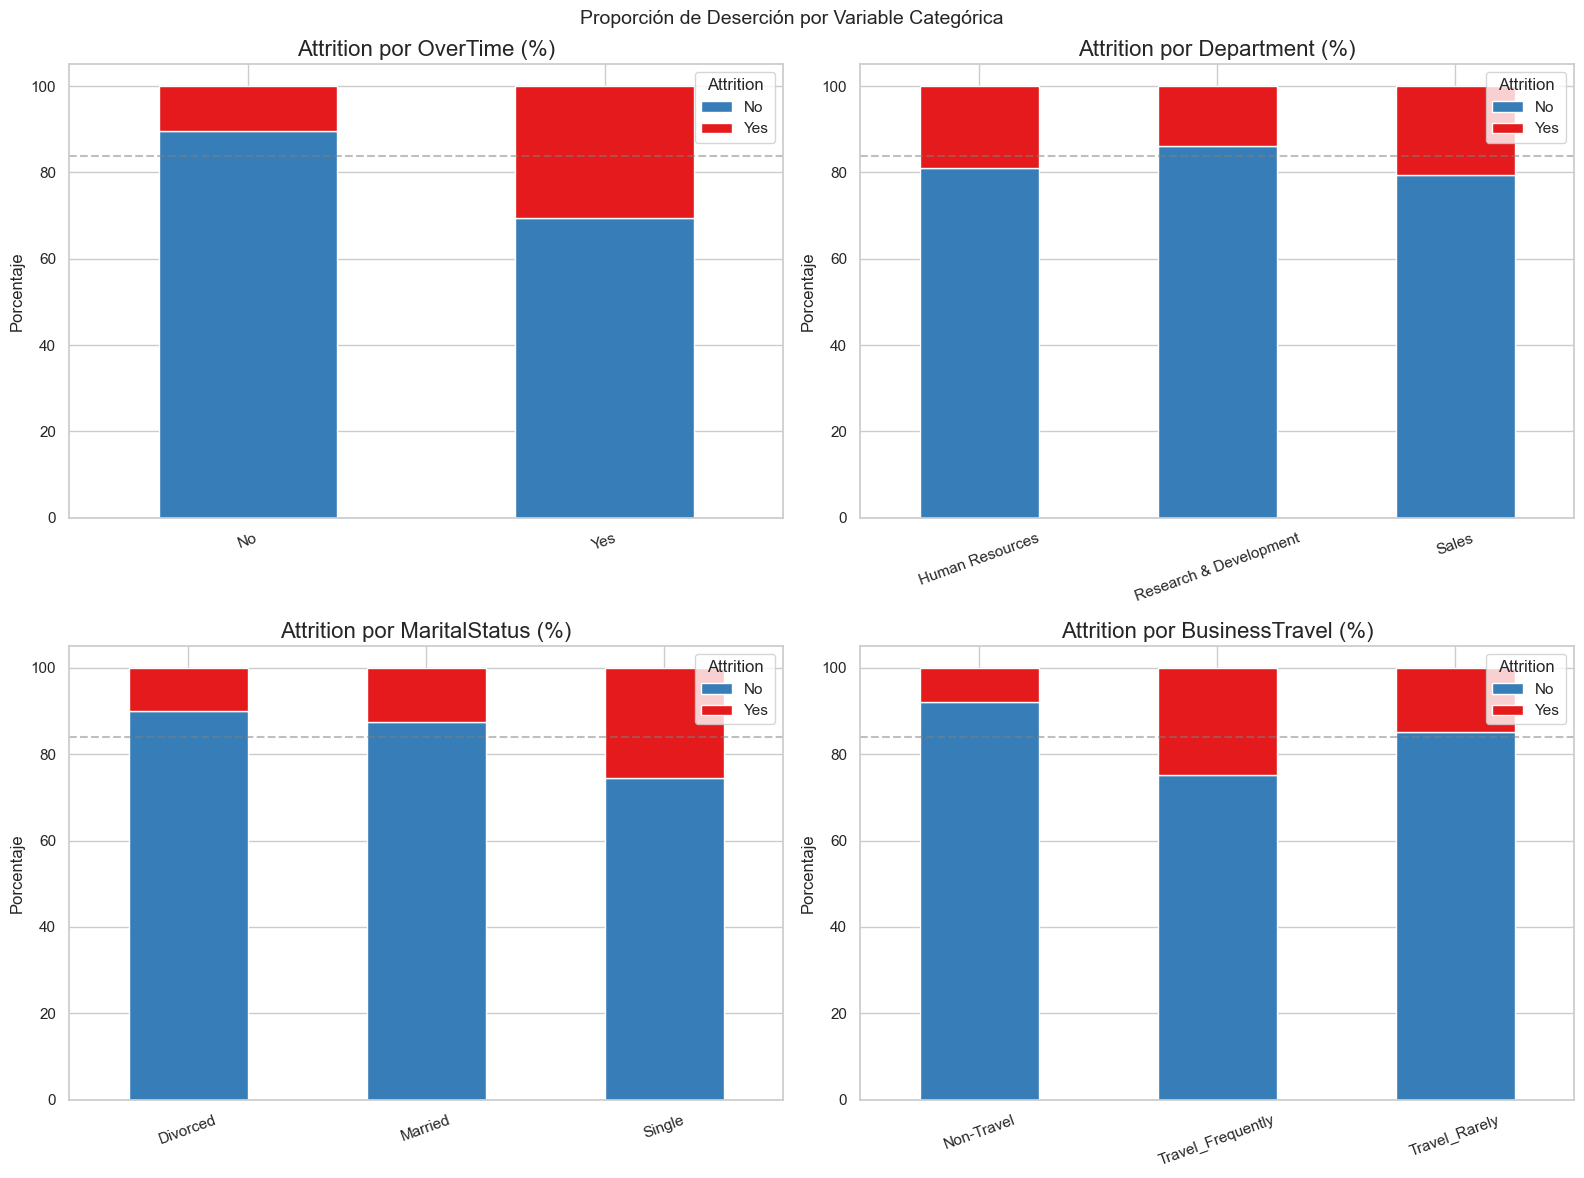


Tabla cruzada: OverTime vs Attrition
Attrition    No   Yes
OverTime             
No         89.6  10.4
Yes        69.5  30.5

Tabla cruzada: Department vs Attrition
Attrition                 No   Yes
Department                        
Human Resources         81.0  19.0
Research & Development  86.2  13.8
Sales                   79.4  20.6

Tabla cruzada: MaritalStatus vs Attrition
Attrition        No   Yes
MaritalStatus            
Divorced       89.9  10.1
Married        87.5  12.5
Single         74.5  25.5

Tabla cruzada: BusinessTravel vs Attrition
Attrition            No   Yes
BusinessTravel               
Non-Travel         92.0   8.0
Travel_Frequently  75.1  24.9
Travel_Rarely      85.0  15.0


In [7]:
# Tablas cruzadas: relaciones categóricas con Attrition
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

cat_vs_attrition = ['OverTime', 'Department', 'MaritalStatus', 'BusinessTravel']

for i, col in enumerate(cat_vs_attrition):
    ct = pd.crosstab(df[col], df['Attrition'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=['#377eb8', '#e41a1c'], edgecolor='white')
    axes[i].set_title(f'Attrition por {col} (%)')
    axes[i].set_ylabel('Porcentaje')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=20)
    axes[i].legend(title='Attrition', loc='upper right')
    # Agregar línea de referencia
    axes[i].axhline(y=83.9, color='gray', linestyle='--', alpha=0.5, label='Base 16.1%')

plt.suptitle('Proporción de Deserción por Variable Categórica', fontsize=14)
plt.tight_layout()
plt.show()

# Imprimir tablas cruzadas numéricas
for var in cat_vs_attrition:
    print(f"\nTabla cruzada: {var} vs Attrition")
    ct = pd.crosstab(df[var], df['Attrition'], normalize='index').mul(100).round(1)
    print(ct)


Los resultados revelan patrones relevantes de deserción por grupo:
- **OverTime**: Los empleados que trabajan horas extra presentan una tasa de Attrition notablemente superior (~30%) frente a quienes no lo hacen (~10%), siendo esta la variable categórica con mayor diferencia entre grupos.
- **Department**: El departamento de Ventas (Sales) muestra la mayor proporción de deserción, seguido por Recursos Humanos, mientras que Investigación y Desarrollo presenta menor rotación relativa.
- **MaritalStatus**: Los empleados solteros tienen mayor propensión a abandonar la empresa en comparación con casados o divorciados, posiblemente por mayor movilidad laboral y menos compromisos financieros.
- **BusinessTravel**: Quienes viajan frecuentemente (`Travel_Frequently`) presentan tasas de Attrition más altas, lo que sugiere que el desgaste asociado a los viajes puede influir en la decisión de retirarse.

En conjunto, estas variables categóricas muestran asociaciones claras con la deserción y deberían considerarse en cualquier modelo predictivo.

Para las variables ordinales tipo Likert (`JobSatisfaction`, `EnvironmentSatisfaction`, `WorkLifeBalance`, `JobInvolvement` y `RelationshipSatisfaction`), que toman valores del 1 al 4, se construyen tablas cruzadas que calculan el porcentaje de empleados con `Attrition=Yes` para cada nivel. Los resultados se grafican como barras por variable, incluyendo una línea de referencia en el 16.1% (promedio global de deserción). Este enfoque permite evaluar si los niveles bajos de satisfacción o compromiso se asocian con mayor riesgo de rotación.

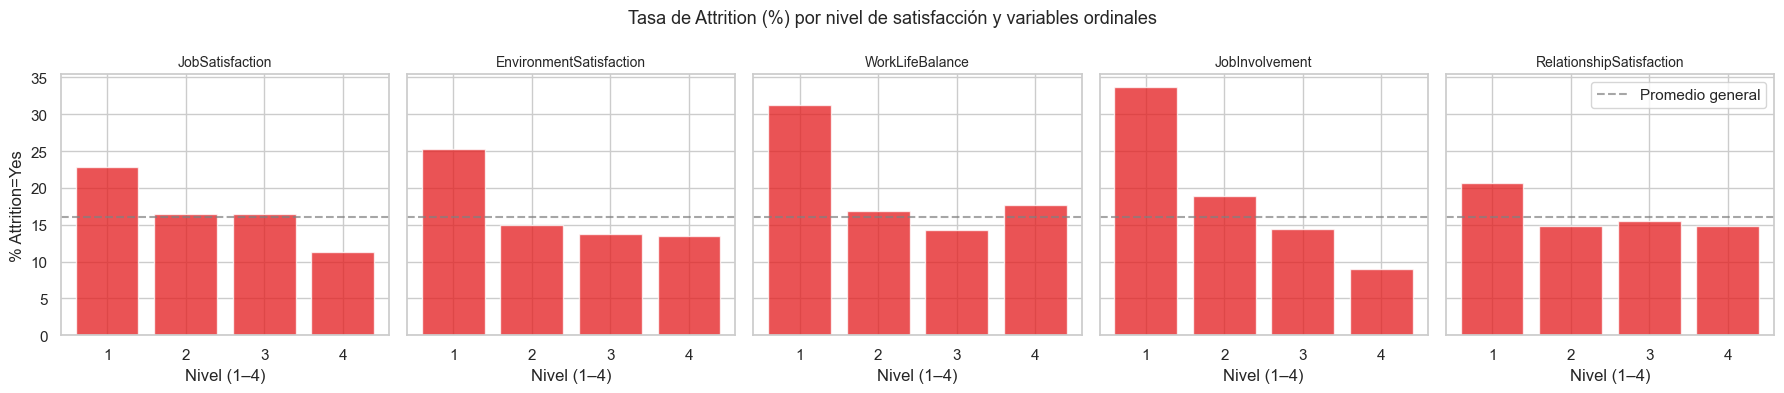


Tabla cruzada: JobSatisfaction vs Attrition
Attrition          No   Yes
JobSatisfaction            
1                77.2  22.8
2                83.6  16.4
3                83.5  16.5
4                88.7  11.3

Tabla cruzada: EnvironmentSatisfaction vs Attrition
Attrition                  No   Yes
EnvironmentSatisfaction            
1                        74.6  25.4
2                        85.0  15.0
3                        86.3  13.7
4                        86.5  13.5

Tabla cruzada: WorkLifeBalance vs Attrition
Attrition          No   Yes
WorkLifeBalance            
1                68.8  31.2
2                83.1  16.9
3                85.8  14.2
4                82.4  17.6

Tabla cruzada: JobInvolvement vs Attrition
Attrition         No   Yes
JobInvolvement            
1               66.3  33.7
2               81.1  18.9
3               85.6  14.4
4               91.0   9.0

Tabla cruzada: RelationshipSatisfaction vs Attrition
Attrition                   No   Yes
Relation

In [26]:
# Tablas cruzadas y gráficos de barras de variables ordinales (satisfacción) vs Attrition
ordinal_vars = ['JobSatisfaction', 'EnvironmentSatisfaction', 
                'WorkLifeBalance', 'JobInvolvement', 'RelationshipSatisfaction']

# Tabla cruzada: proporción de Attrition=Yes por nivel de cada variable ordinal
fig, axes = plt.subplots(1, len(ordinal_vars), figsize=(18, 4), sharey=True)

for ax, var in zip(axes, ordinal_vars):
    ct = pd.crosstab(df[var], df['Attrition'], normalize='index')['Yes'] * 100
    ax.bar(ct.index, ct.values, color='#e41a1c', alpha=0.75, edgecolor='white')
    ax.set_title(var, fontsize=10)
    ax.set_xlabel('Nivel (1–4)')
    ax.set_ylabel('% Attrition=Yes' if ax == axes[0] else '')
    ax.axhline(y=16.1, color='gray', linestyle='--', alpha=0.7, label='Promedio general')
    ax.set_xticks(ct.index)

axes[-1].legend(loc='upper right')
plt.suptitle('Tasa de Attrition (%) por nivel de satisfacción y variables ordinales', fontsize=13)
plt.tight_layout()
plt.show()

# Imprimir tablas cruzadas numéricas
for var in ordinal_vars:
    print(f"\nTabla cruzada: {var} vs Attrition")
    ct = pd.crosstab(df[var], df['Attrition'], normalize='index').mul(100).round(1)
    print(ct)


Se observa una tendencia general en la que los niveles más bajos de satisfacción (nivel 1) se asocian con tasas de Attrition más altas, superando en varios casos el promedio global del 16.1%:
- **JobSatisfaction** y **EnvironmentSatisfaction**: El nivel 1 registra las mayores tasas de deserción (~22–25%), confirmando que empleados insatisfechos con su trabajo o su ambiente tienen mayor probabilidad de irse.
- **WorkLifeBalance**: El nivel 1 también destaca como el más crítico, lo que sugiere que un mal equilibrio entre vida personal y laboral es un factor de riesgo importante.
- **JobInvolvement**: Los empleados con bajo involucramiento (nivel 1) muestran la mayor tasa de Attrition, lo cual es consistente con la hipótesis de que el desenganche precede a la renuncia.
- **RelationshipSatisfaction**: Aunque también muestra la tendencia esperada, su efecto es algo menos pronunciado que las demás variables.

Estos hallazgos son valiosos porque muestran que la insatisfacción en múltiples dimensiones se acumula y potencia el riesgo de deserción.

Se genera una matriz de correlación de Pearson para todas las variables numéricas del dataset (excluyendo identificadores sin valor analítico como `EmployeeNumber`, `EmployeeCount` y `StandardHours`). Para facilitar la lectura, se aplica una máscara que oculta el triángulo superior, ya que la matriz es simétrica. El mapa de calor usa una escala divergente (`RdBu_r`) centrada en 0, donde los tonos rojos indican correlación positiva y los azules correlación negativa. Adicionalmente, se identifican y listan los 10 pares de variables con mayor correlación en valor absoluto.

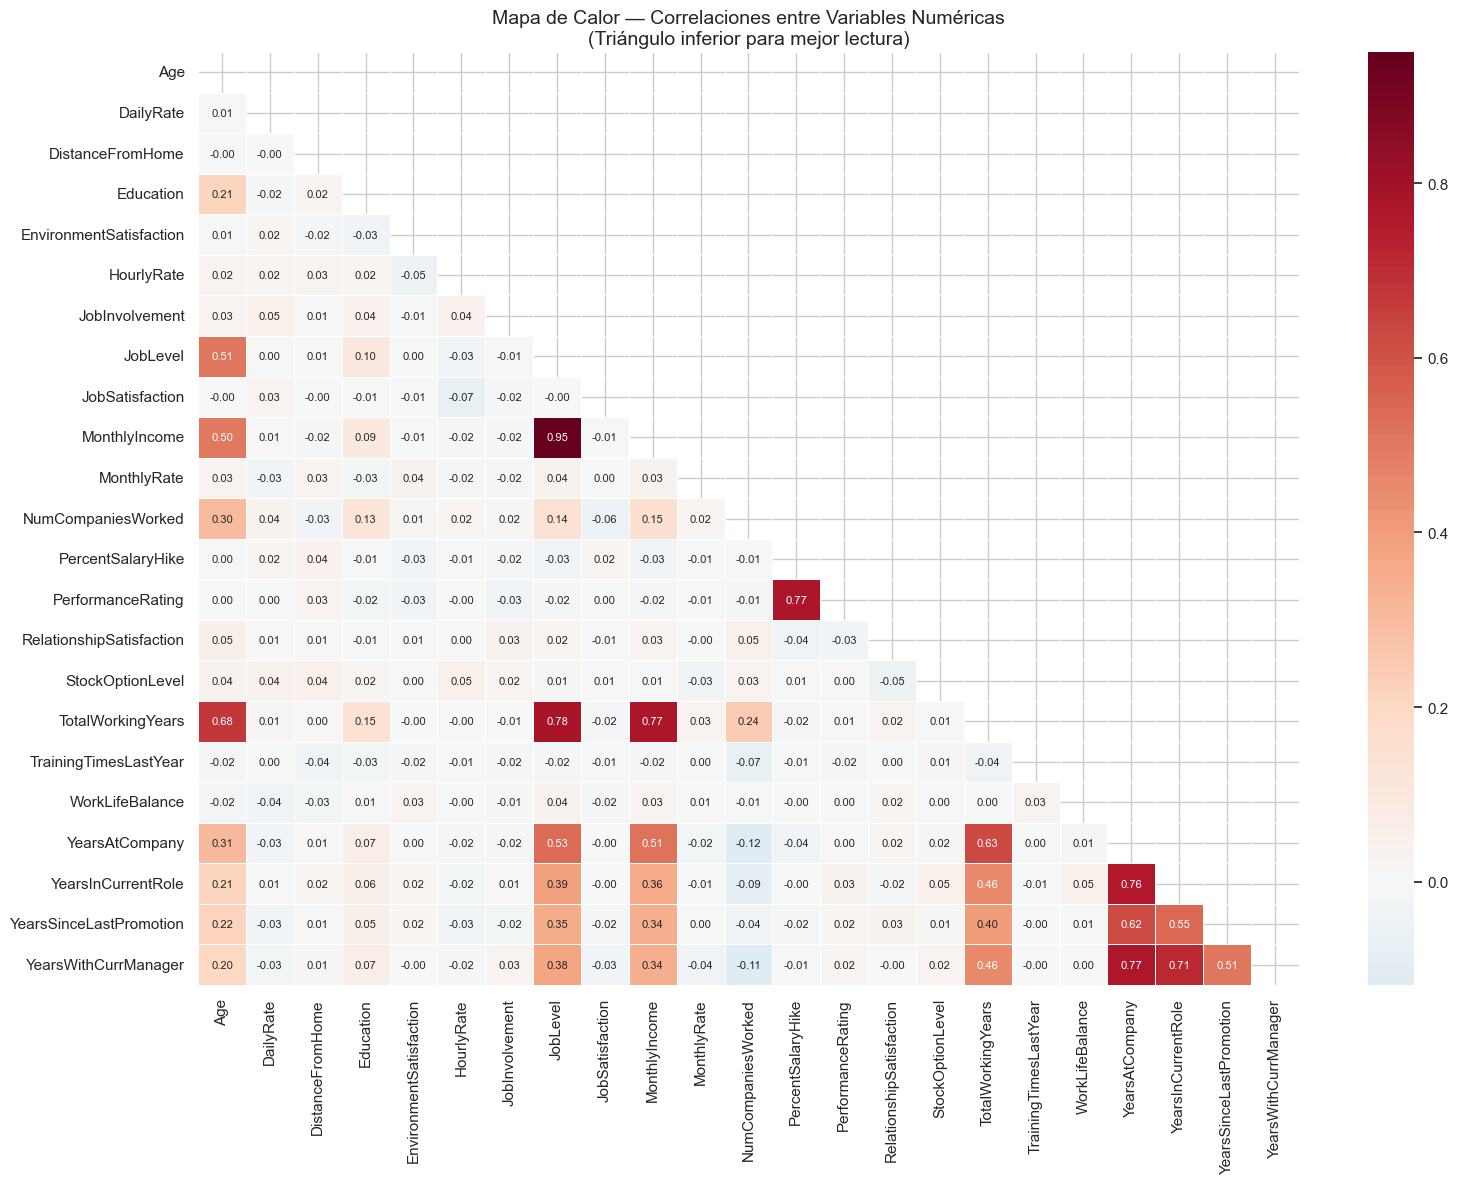


Top 10 pares de variables más correlacionadas:
  MonthlyIncome ↔ JobLevel: 0.950
  TotalWorkingYears ↔ JobLevel: 0.782
  PerformanceRating ↔ PercentSalaryHike: 0.774
  TotalWorkingYears ↔ MonthlyIncome: 0.773
  YearsWithCurrManager ↔ YearsAtCompany: 0.769
  YearsInCurrentRole ↔ YearsAtCompany: 0.759
  YearsWithCurrManager ↔ YearsInCurrentRole: 0.714
  TotalWorkingYears ↔ Age: 0.680
  YearsAtCompany ↔ TotalWorkingYears: 0.628
  YearsSinceLastPromotion ↔ YearsAtCompany: 0.618


In [11]:
# Mapa de calor de correlaciones numéricas
numeric_df = df.select_dtypes(include=[np.number]).drop(
    columns=['EmployeeCount', 'EmployeeNumber', 'StandardHours'], errors='ignore'
)

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))  # Máscara triángulo superior
sns.heatmap(
    numeric_df.corr(), 
    annot=True, fmt='.2f', 
    cmap='RdBu_r', center=0,
    mask=mask,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Mapa de Calor — Correlaciones entre Variables Numéricas\n(Triángulo inferior para mejor lectura)', fontsize=14)
plt.tight_layout()
plt.show()

# Top correlaciones (en valor absoluto)
corr_matrix = numeric_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
top_corr = upper.unstack().sort_values(ascending=False).head(10)
print("\nTop 10 pares de variables más correlacionadas:")
for (v1, v2), val in top_corr.items():
    print(f"  {v1} ↔ {v2}: {val:.3f}")

El mapa de calor revela varios grupos de variables fuertemente correlacionadas:
- **Experiencia y edad**: `Age`, `TotalWorkingYears`, `YearsAtCompany`, `YearsInCurrentRole` y `YearsWithCurrManager` forman un clúster de alta correlación positiva (>0.6 en varios pares), lo que es esperable dado que todas miden dimensiones de antigüedad y trayectoria.
- **Ingreso y jerarquía**: `MonthlyIncome` y `JobLevel` presentan una correlación muy alta (>0.9), indicando que el nivel del puesto es el principal determinante del salario dentro de la empresa.
- **Correlaciones débiles con Attrition**: Variables como `Age`, `TotalWorkingYears` y `MonthlyIncome` muestran correlaciones negativas moderadas con Attrition (empleados más jóvenes, con menos experiencia y menor salario tienden a abandonar más), aspecto que se profundiza en el análisis de correlación directa con Attrition.
- **Variables con poca correlación**: `DailyRate`, `HourlyRate` y `MonthlyRate` presentan correlaciones bajas con casi todo el resto del dataset, lo que sugiere que estas tasas de pago puntuales no capturan bien la estructura salarial real.

El pairplot es una herramienta de visualización multivariada que muestra, de forma simultánea, los diagramas de dispersión entre cada par de variables seleccionadas, junto con la distribución individual de cada variable en la diagonal (usando estimación de densidad KDE). Se seleccionaron cuatro variables numéricas clave — `Age`, `MonthlyIncome`, `TotalWorkingYears` y `YearsAtCompany` — y se colorea cada punto según el valor de `Attrition` (rojo para `Yes`, azul para `No`). Esto permite detectar visualmente si existe separación espacial entre ambos grupos.

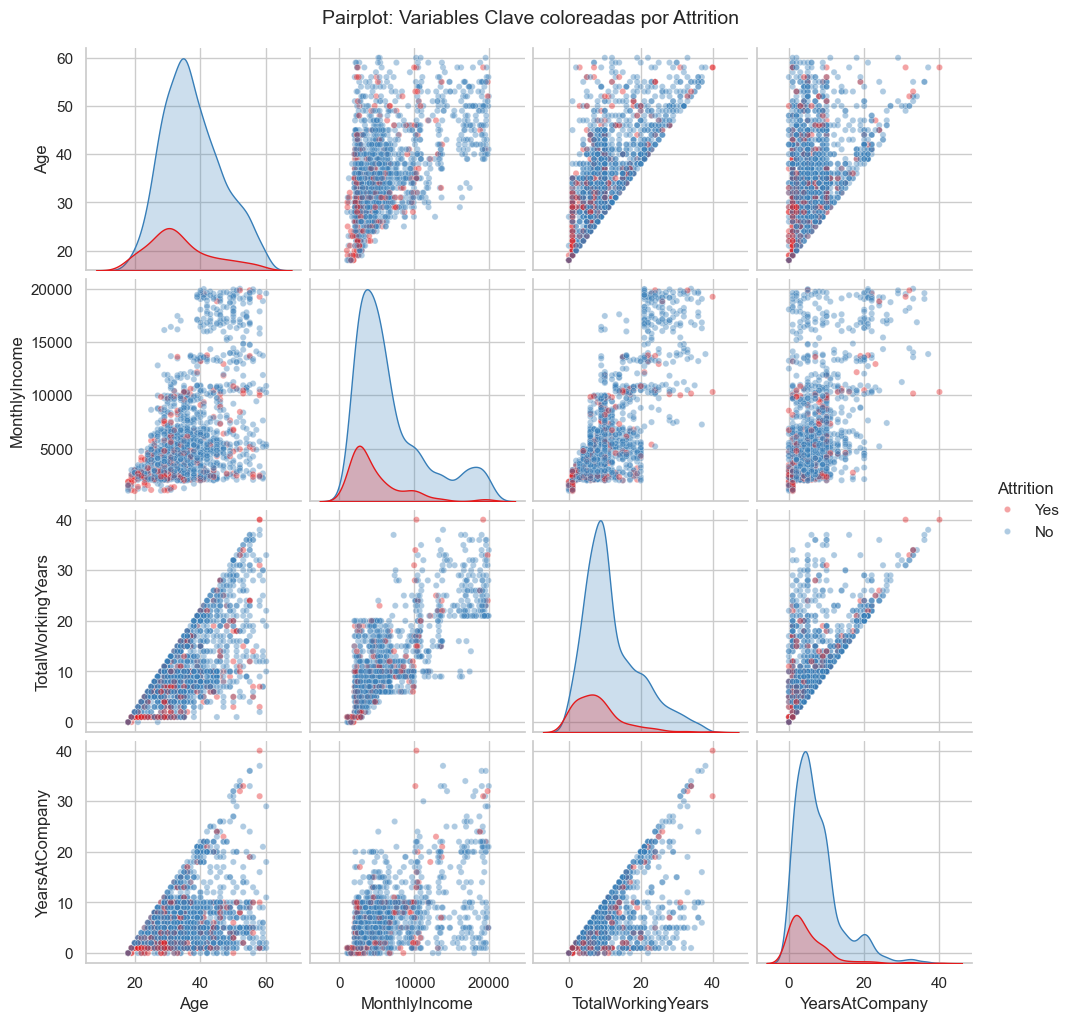

In [12]:
# Pairplot: variables clave vs Attrition
# El pairplot muestra diagramas de dispersión entre múltiples variables
# y resalta si hay diferencias por grupo (Attrition: Yes/No)

vars_pairplot = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'Attrition']

pp = sns.pairplot(
    df[vars_pairplot], 
    hue='Attrition', 
    palette={'Yes': '#e41a1c', 'No': '#377eb8'},
    plot_kws={'alpha': 0.4, 's': 20},
    diag_kind='kde'
)
pp.figure.suptitle('Pairplot: Variables Clave coloreadas por Attrition', y=1.02, fontsize=14)
plt.show()

El pairplot confirma de manera visual los patrones identificados en análisis anteriores:
- **Separación por grupos**: Los puntos rojos (`Attrition=Yes`) se concentran consistentemente en las regiones de valores bajos de todas las variables, mientras que los azules (`Attrition=No`) se distribuyen de forma más amplia, incluyendo valores altos.
- **Age vs MonthlyIncome**: Se aprecia una zona de alta densidad roja en edades 20–35 con ingresos menores a $4,000, indicando que los empleados jóvenes y mal remunerados son el segmento más vulnerable.
- **TotalWorkingYears vs MonthlyIncome**: Refuerza la relación entre experiencia e ingresos, y muestra que quienes abandonan tienen pocas credenciales de ambas variables.
- **YearsAtCompany**: Las KDEs en la diagonal muestran que los empleados que se van tienen distribuciones claramente desplazadas hacia valores bajos de antigüedad, confirmando que la rotación ocurre principalmente en los primeros años.

En síntesis, el pairplot es útil como visualización de resumen: evidencia que `Attrition=Yes` no es aleatorio, sino que se concentra en un perfil definido de empleado joven, con poca experiencia y bajo ingreso.

Para cuantificar directamente el efecto de cada variable numérica sobre la deserción, se codifica `Attrition` como variable binaria (0 = No, 1 = Yes) y se calcula el coeficiente de correlación de Pearson entre cada predictor numérico y esta variable objetivo. Los valores se ordenan por magnitud y se grafican como barras horizontales, diferenciando con rojo las correlaciones positivas (mayor valor → más riesgo de irse) y azul las negativas (mayor valor → menos riesgo).

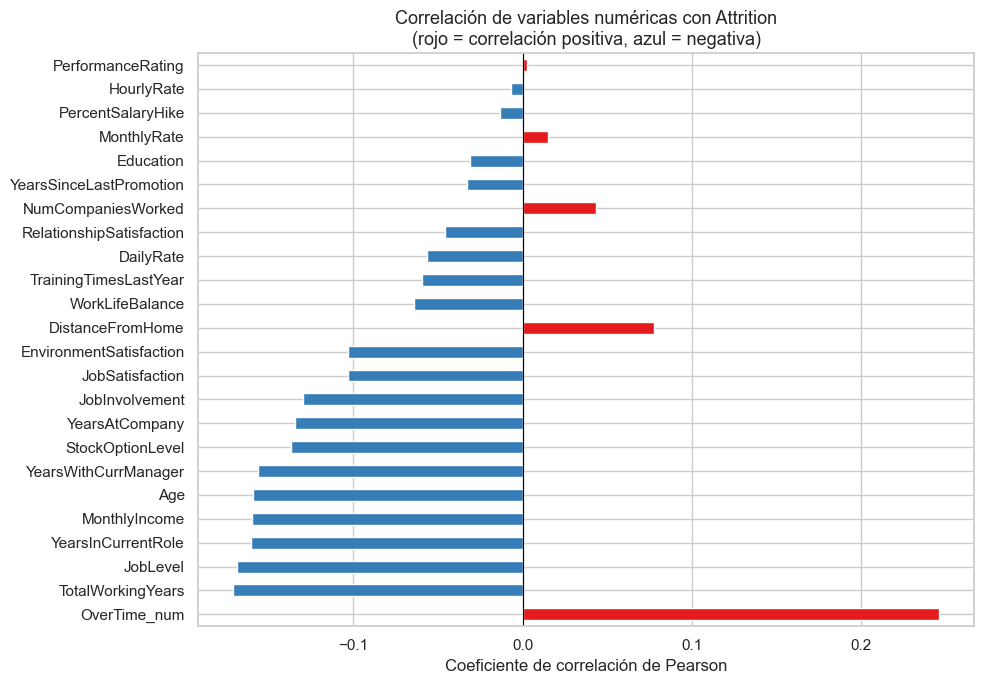

Correlaciones con Attrition (ordenadas por magnitud):
OverTime_num                0.246
TotalWorkingYears          -0.171
JobLevel                   -0.169
YearsInCurrentRole         -0.161
MonthlyIncome              -0.160
Age                        -0.159
YearsWithCurrManager       -0.156
StockOptionLevel           -0.137
YearsAtCompany             -0.134
JobInvolvement             -0.130
JobSatisfaction            -0.103
EnvironmentSatisfaction    -0.103
DistanceFromHome            0.078
WorkLifeBalance            -0.064
TrainingTimesLastYear      -0.059
DailyRate                  -0.057
RelationshipSatisfaction   -0.046
NumCompaniesWorked          0.043
YearsSinceLastPromotion    -0.033
Education                  -0.031
MonthlyRate                 0.015
PercentSalaryHike          -0.013
HourlyRate                 -0.007
PerformanceRating           0.003


In [27]:
# Correlación de variables numéricas con Attrition
# Codificamos Attrition como 0/1 para poder correlacionar
df['Attrition_num'] = (df['Attrition'] == 'Yes').astype(int)

# Codificamos Overtime para añadirla al pool de columnas numéricas, pues esta tiene fuerte relación con Attrition
df['OverTime_num'] = (df['OverTime'] == 'Yes').astype(int)

numeric_cols = df.select_dtypes(include=[np.number]).drop(
    columns=['EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Attrition_num'], 
    errors='ignore'
).columns

corr_attrition = df[numeric_cols].corrwith(df['Attrition_num']).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 7))
colors = ['#e41a1c' if v > 0 else '#377eb8' for v in corr_attrition]
corr_attrition.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlación de variables numéricas con Attrition\n(rojo = correlación positiva, azul = negativa)', fontsize=13)
plt.xlabel('Coeficiente de correlación de Pearson')
plt.tight_layout()
plt.show()

print("Correlaciones con Attrition (ordenadas por magnitud):")
print(corr_attrition.round(3).to_string())

Las correlaciones con Attrition revelan qué variables numéricas tienen mayor poder predictivo individual:
- **Correlaciones negativas más fuertes** (protectoras contra la deserción): `TotalWorkingYears`, `Age`, `YearsInCurrentRole`, `MonthlyIncome` y `YearsAtCompany`. Esto confirma que a mayor experiencia, antigüedad e ingreso, menor es la probabilidad de abandono.
- **Correlaciones positivas** (factores de riesgo): `OverTime`, `DistanceFromHome` y `NumCompaniesWorked` aparecen como variables asociadas positivamente con Attrition, indicando que vivir lejos del trabajo o haber rotado por muchas empresas aumenta el riesgo.
- **Variables sin correlación relevante**: `DailyRate`, `HourlyRate`, `MonthlyRate` y `PercentSalaryHike` presentan correlaciones cercanas a cero, lo que sugiere que no son buenos predictores de deserción de forma aislada.

Este análisis prioriza qué variables deberían considerarse primero en un modelo predictivo de Attrition.

Se construyen tres diagramas de dispersión para pares de variables de especial interés analítico, coloreando cada punto según `Attrition`. Los pares seleccionados son: `Age` vs `MonthlyIncome`, `TotalWorkingYears` vs `MonthlyIncome`, y `YearsAtCompany` vs `YearsSinceLastPromotion`. Esta visualización complementa el pairplot al mostrar con mayor detalle la distribución espacial de ambos grupos en cada relación bivariada.

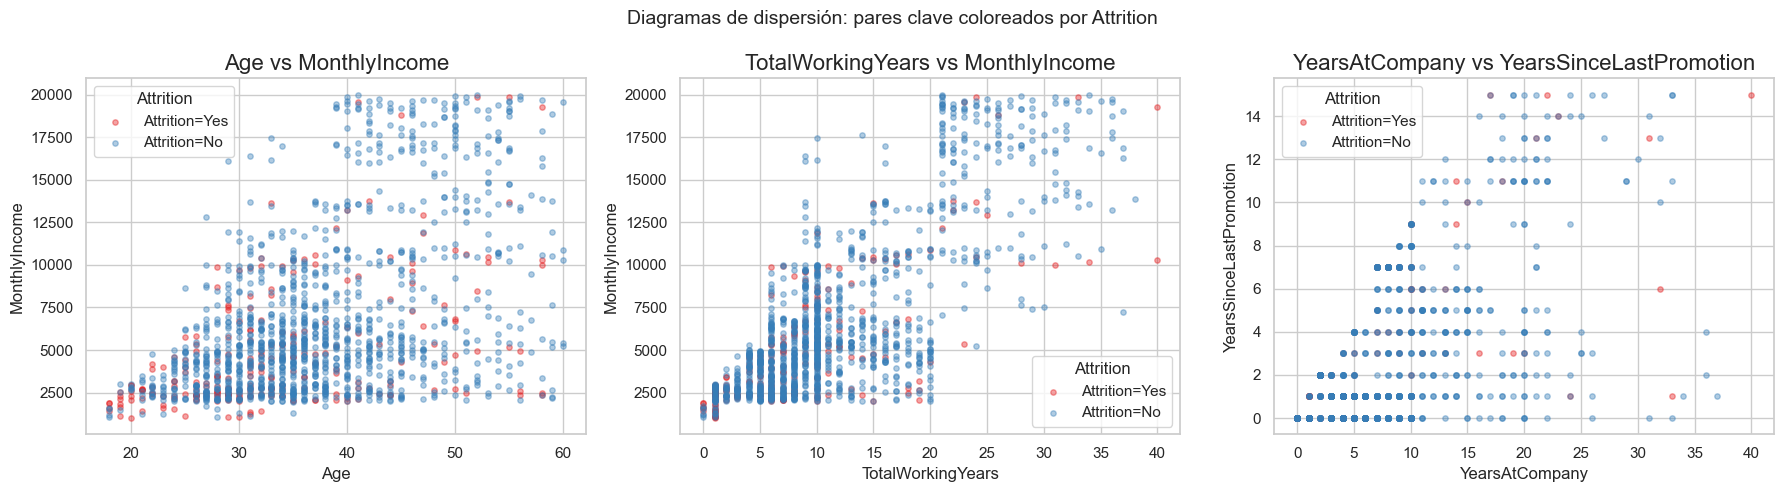

In [14]:
# Diagramas de dispersión: pares clave coloreados por Attritio
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter_pairs = [
    ('Age', 'MonthlyIncome'),
    ('TotalWorkingYears', 'MonthlyIncome'),
    ('YearsAtCompany', 'YearsSinceLastPromotion'),
]

palette = {'Yes': '#e41a1c', 'No': '#377eb8'}

for ax, (x_var, y_var) in zip(axes, scatter_pairs):
    for group, color in palette.items():
        subset = df[df['Attrition'] == group]
        ax.scatter(subset[x_var], subset[y_var], 
                   c=color, alpha=0.4, s=15, label=f'Attrition={group}')
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_title(f'{x_var} vs {y_var}')
    ax.legend(title='Attrition')

plt.suptitle('Diagramas de dispersión: pares clave coloreados por Attrition', fontsize=14)
plt.tight_layout()
plt.show()

Los diagramas de dispersión aportan claridad sobre la segmentación entre grupos:
- **Age vs MonthlyIncome**: La concentración de puntos rojos en la esquina inferior izquierda (edades bajas, ingresos bajos) es marcada. Los empleados que se van raramente tienen altos ingresos, independientemente de su edad.
- **TotalWorkingYears vs MonthlyIncome**: Patrón similar: la deserción ocurre casi exclusivamente entre quienes tienen menos de 10 años de experiencia y menos de $5,000 de ingreso mensual, confirmando que la retención mejora con la trayectoria profesional.
- **YearsAtCompany vs YearsSinceLastPromotion**: Aquí aparece un patrón interesante — empleados con varios años en la empresa pero sin ascensos recientes también presentan deserción, lo que sugiere que el estancamiento en el desarrollo de carrera puede ser un factor detonante independiente del salario.

En conjunto, estos scatter plots refuerzan la narrativa de que la deserción responde a un perfil multidimensional: empleados jóvenes, de bajos ingresos, con poca experiencia y sin promociones recientes.

### 2.6 Construcción de Hipótesis Iniciales

A partir de los patrones observados a lo largo del EDA, se plantean las siguientes hipótesis 
verificables con el dataset. Cada una está fundamentada en evidencia encontrada en las 
secciones anteriores y podrá ser contrastada estadísticamente en la Fase 3.

#### Hipótesis 1 — Sobrecarga Laboral
*"Los empleados que realizan horas extra (`OverTime=Yes`) tienen una tasa de deserción 
significativamente superior a quienes no lo hacen."*

**Justificación:** El análisis de tablas cruzadas (sección 2.5) muestra una tasa de Attrition 
de aproximadamente el 30% para empleados con `OverTime=Yes`, frente a un 10% para quienes 
no realizan horas extra. Esta diferencia triplica la tasa base del dataset (16.1%) y convierte 
a `OverTime` en el factor categórico más discriminante observado en el EDA.


#### Hipótesis 2 — Estabilidad Financiera
*"Existe una relación inversa entre `MonthlyIncome` y Attrition: a menor ingreso mensual, 
mayor probabilidad de deserción."*

**Justificación:** El pairplot (sección 2.5) muestra que los empleados que abandonaron la 
empresa se concentran consistentemente en los rangos de ingreso más bajos, por debajo de 
$4,000 mensuales. Esto es confirmado por el gráfico de correlación directa con Attrition, 
donde `MonthlyIncome` figura entre las variables con correlación negativa más fuerte junto 
con `TotalWorkingYears` y `JobLevel`.


#### Hipótesis 3 — Antigüedad como Factor Protector
*"Los primeros 2 años en la empresa concentran el mayor riesgo de deserción; a partir del 
año 5, el riesgo disminuye sustancialmente."*

**Justificación:** Las curvas KDE del pairplot (sección 2.5) para `YearsAtCompany` muestran 
que la distribución de empleados con `Attrition=Yes` se desplaza claramente hacia valores 
bajos de antigüedad, con la mayor densidad en los primeros años. El diagrama de dispersión 
`YearsAtCompany vs YearsSinceLastPromotion` confirma que la deserción cae drásticamente 
a partir del quinto año.


#### Hipótesis 4 — Distancia al Trabajo
*"Los empleados que viven más lejos del trabajo presentan mayor probabilidad de desertar, 
especialmente cuando esta condición se combina con bajos ingresos."*

**Justificación:** `DistanceFromHome` aparece con correlación positiva con Attrition en el 
gráfico de correlación directa con la variable objetivo (sección 2.5). Si bien es débil de 
forma aislada, se plantea como hipótesis para verificar si su efecto se amplifica en 
combinación con otras variables de riesgo como el ingreso bajo o la realización de horas extra.


#### Hipótesis 5 — Insatisfacción Acumulada
*"Los empleados con niveles bajos simultáneos en `JobSatisfaction`, `EnvironmentSatisfaction` 
y `WorkLifeBalance` presentan una tasa de deserción significativamente superior al promedio, 
sugiriendo que la insatisfacción en múltiples dimensiones tiene un efecto acumulativo."*

**Justificación:** El análisis de variables ordinales (sección 2.5) muestra que cada una de 
estas variables por separado registra tasas de Attrition superiores al 16.1% en su nivel 
más bajo. El nivel 1 de `JobSatisfaction` y `EnvironmentSatisfaction` alcanza tasas de 
deserción de entre el 22% y el 25%, y el patrón se repite en `WorkLifeBalance` y 
`JobInvolvement`, lo que sugiere que sus efectos no son independientes.

### 2.7 Insights Principales

A continuación se resumen los patrones más relevantes encontrados durante el EDA, los 
problemas de calidad detectados en el dataset y las líneas de análisis propuestas para 
la siguiente fase.

#### Patrones Relevantes

**Insight 1 — Dataset desbalanceado (crítico para el modelado)**
`Attrition=Yes` representa únicamente el 16.1% de los registros (237 de 1,470 empleados), 
dato calculado al inicio de la Fase 2. Esto implica que un modelo que prediga siempre "No" 
alcanzaría un 83.9% de accuracy sin aprender ningún patrón real. Para la Fase 3 será 
necesario aplicar técnicas de balanceo como SMOTE o pesos de clase, y evaluar el rendimiento 
con métricas apropiadas para clases desbalanceadas como F1-score y AUC-ROC.


**Insight 2 — OverTime es el predictor categórico más discriminante**
Los empleados con `OverTime=Yes` presentan una tasa de deserción del ~30%, frente al ~10% 
de quienes no realizan horas extra, según las tablas cruzadas de la sección 2.5. Esta 
diferencia es la más pronunciada observada entre todas las variables categóricas analizadas 
y se ve reforzada por la correlación positiva de `OverTime_num` con Attrition en el gráfico 
de correlación directa.


**Insight 3 — Los primeros años en la empresa son los de mayor riesgo**
Las curvas KDE del pairplot y el diagrama de dispersión `YearsAtCompany vs YearsSinceLastPromotion` 
(sección 2.5) muestran que la deserción se concentra en los primeros 1–2 años y cae 
drásticamente a partir del año 5. Esto indica que el período de incorporación es la ventana 
crítica para la retención, y que los programas de onboarding y acompañamiento temprano 
podrían tener el mayor impacto en reducir la rotación.


**Insight 4 — El departamento de Ventas concentra la mayor tasa de rotación**
Las tablas cruzadas de `Department` vs `Attrition` (sección 2.5) muestran que Sales presenta 
la mayor proporción de deserción entre los tres departamentos, seguido de Human Resources. 
Research & Development, pese a ser el departamento más numeroso según los gráficos de 
frecuencia de la sección 2.4, registra la tasa más baja, lo que sugiere diferencias 
estructurales en condiciones laborales y presión entre áreas.


**Insight 5 — Multicolinealidad entre variables de experiencia e ingreso**
El mapa de calor de correlaciones (sección 2.5) muestra que `TotalWorkingYears` y `JobLevel` 
presentan correlaciones aproximadas de 0.78 y 0.77 con `MonthlyIncome` respectivamente. 
Si bien esto no afecta modelos basados en árboles como Random Forest o XGBoost, sí puede 
distorsionar coeficientes en modelos lineales, requiriendo técnicas como PCA o selección 
de variables antes del entrenamiento.


#### Problemas de Calidad Detectados

**Insight 6 — Variables sin poder predictivo ni variabilidad**
Tres variables del dataset presentan valor constante en todos los registros y fueron 
excluidas explícitamente del análisis desde la sección 2.5: `EmployeeCount` (siempre 1), 
`StandardHours` (siempre 80) y `Over18` (siempre 'Y'). Adicionalmente, el gráfico de 
correlación directa con Attrition (sección 2.5) muestra que `DailyRate`, `HourlyRate` y 
`MonthlyRate` presentan correlaciones cercanas a cero, cuestionando su utilidad como 
predictores en la Fase 3.


#### Líneas de Análisis para la Fase 3

**Insight 7 — Hoja de ruta para el modelado predictivo**
Con base en los hallazgos del EDA, se proponen tres direcciones concretas para la siguiente fase:

- **Modelado:** Construir un clasificador binario de Attrition utilizando algoritmos como 
  Random Forest o XGBoost, que manejan bien la multicolinealidad, el desbalance de clases 
  y las relaciones no lineales observadas en los datos.

- **Preprocesamiento:** Aplicar transformaciones logarítmicas a `MonthlyIncome`, 
  `YearsAtCompany` y `YearsSinceLastPromotion` antes del entrenamiento, dado el sesgo 
  positivo alto identificado en la sección 2.3.

- **Ingeniería de features:** Explorar la creación de variables combinadas que capturen 
  interacciones detectadas en el EDA, como la combinación de `OverTime` con `MonthlyIncome`, 
  o un índice de insatisfacción que agregue `JobSatisfaction`, `EnvironmentSatisfaction` y 
  `WorkLifeBalance` en una sola variable compuesta.